# Importing Packages & Files

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.mixture import GaussianMixture

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [4]:
bankchurners = 'BankChurners.csv'

df = pd.read_csv(bankchurners)

# EDA

## Data Cleaning

In [5]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [6]:
df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [8]:
df.duplicated().sum()

np.int64(0)

## Visualising the Distribution of Features

### Numerical Features

#### Customer Attributes

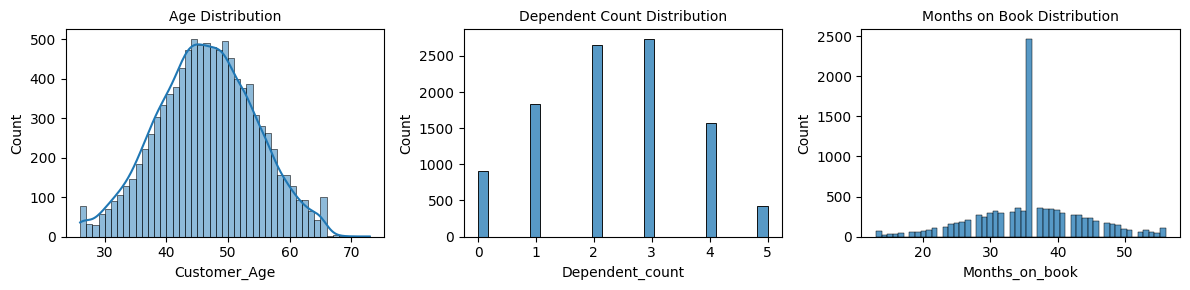

In [9]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Plot Age Distribution
sns.histplot(df['Customer_Age'], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution", fontsize=10)

# Plot Dependent Count Distribution
sns.histplot(df['Dependent_count'], ax=axes[1])
axes[1].set_title("Dependent Count Distribution", fontsize=10)

# Plot Months_on_book Distribution
sns.histplot(x=df['Months_on_book'], ax=axes[2])
axes[2].set_title("Months on Book Distribution", fontsize=10)


# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

#### Transactional Data

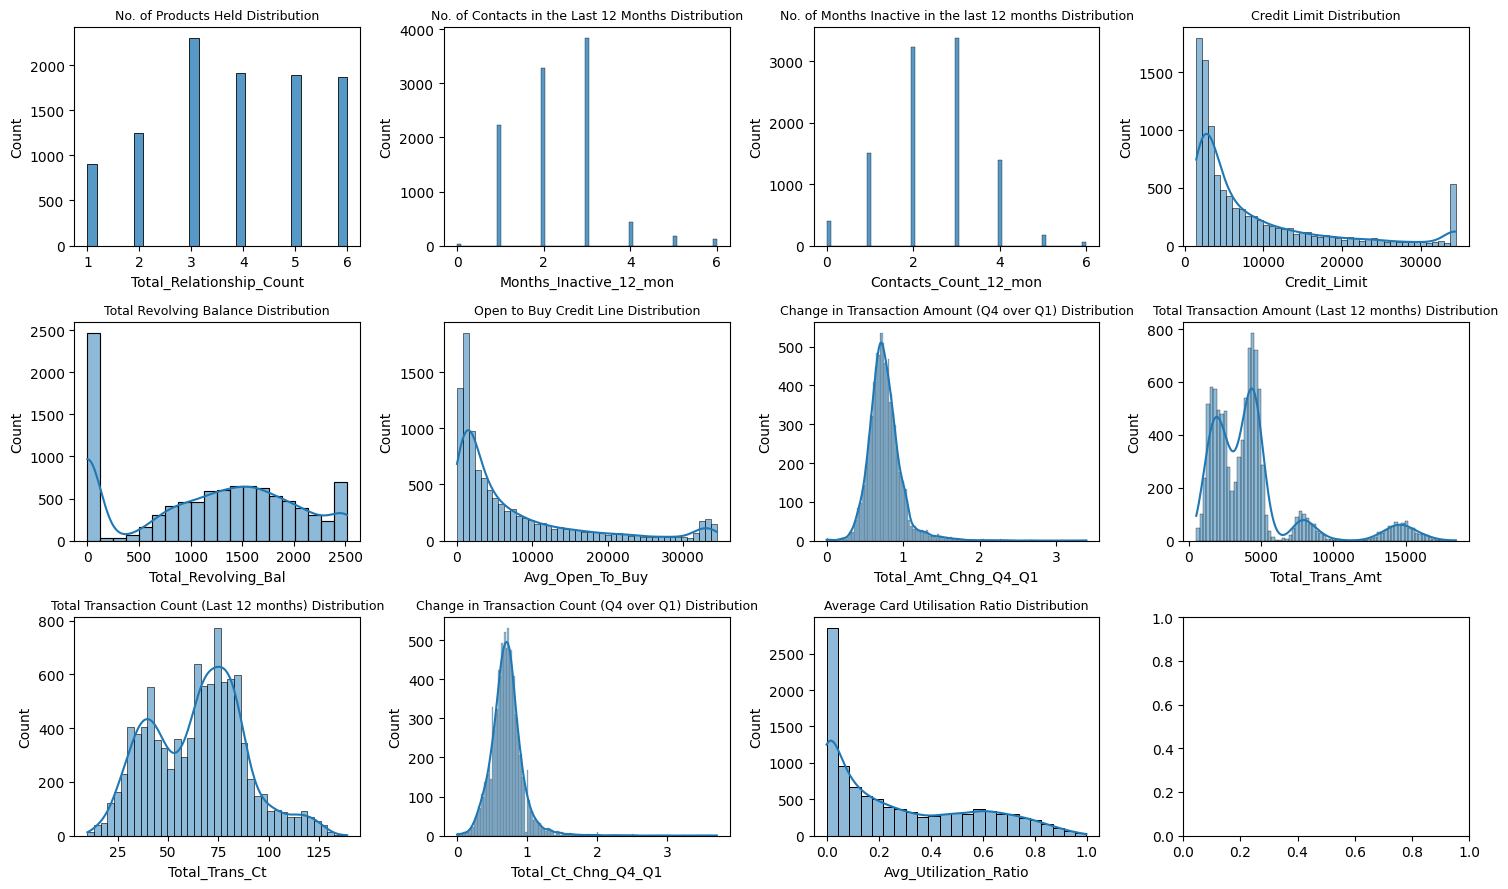

In [10]:
# Create a figure with 3 row and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(15, 9))

# Plot Total_Relationship_Count Distribution
sns.histplot(df['Total_Relationship_Count'], ax=axes[0,0])
axes[0,0].set_title("No. of Products Held Distribution", fontsize=9)

# Plot Months_Inactive_12_mon Distribution
sns.histplot(df['Months_Inactive_12_mon'], ax=axes[0,1])
axes[0,1].set_title("No. of Contacts in the Last 12 Months Distribution", fontsize=9)

# Plot Contacts_Count_12_mon Distribution
sns.histplot(x=df['Contacts_Count_12_mon'], ax=axes[0,2])
axes[0,2].set_title("No. of Months Inactive in the last 12 months Distribution", fontsize=9)

# Plot Credit_Limit Distribution
sns.histplot(df['Credit_Limit'], kde=True, ax=axes[0,3])
axes[0,3].set_title("Credit Limit Distribution", fontsize=9)

# Plot Total_Revolving_Bal Distribution
sns.histplot(df['Total_Revolving_Bal'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Total Revolving Balance Distribution", fontsize=9)

# Plot Avg_Open_To_Buy Distribution
sns.histplot(x=df['Avg_Open_To_Buy'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Open to Buy Credit Line Distribution", fontsize=9)

# Plot Total_Amt_Chng_Q4_Q1 Distribution
sns.histplot(df['Total_Amt_Chng_Q4_Q1'], kde=True, ax=axes[1,2])
axes[1,2].set_title("Change in Transaction Amount (Q4 over Q1) Distribution", fontsize=9)

# Plot Total_Trans_Amt Distribution
sns.histplot(x=df['Total_Trans_Amt'], kde=True, ax=axes[1,3])
axes[1,3].set_title("Total Transaction Amount (Last 12 months) Distribution", fontsize=9)

# Plot Total_Trans_Ct Distribution
sns.histplot(x=df['Total_Trans_Ct'], kde=True, ax=axes[2,0])
axes[2,0].set_title("Total Transaction Count (Last 12 months) Distribution", fontsize=9)

# Plot Total_Ct_Chng_Q4_Q1 Distribution
sns.histplot(df['Total_Ct_Chng_Q4_Q1'], kde=True, ax=axes[2,1])
axes[2,1].set_title("Change in Transaction Count (Q4 over Q1) Distribution", fontsize=9)

# Plot Avg_Utilization_Ratio Distribution
sns.histplot(x=df['Avg_Utilization_Ratio'], kde=True, ax=axes[2,2])
axes[2,2].set_title("Average Card Utilisation Ratio Distribution", fontsize=9)


# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

### Categorical Features

#### Customer Attributes

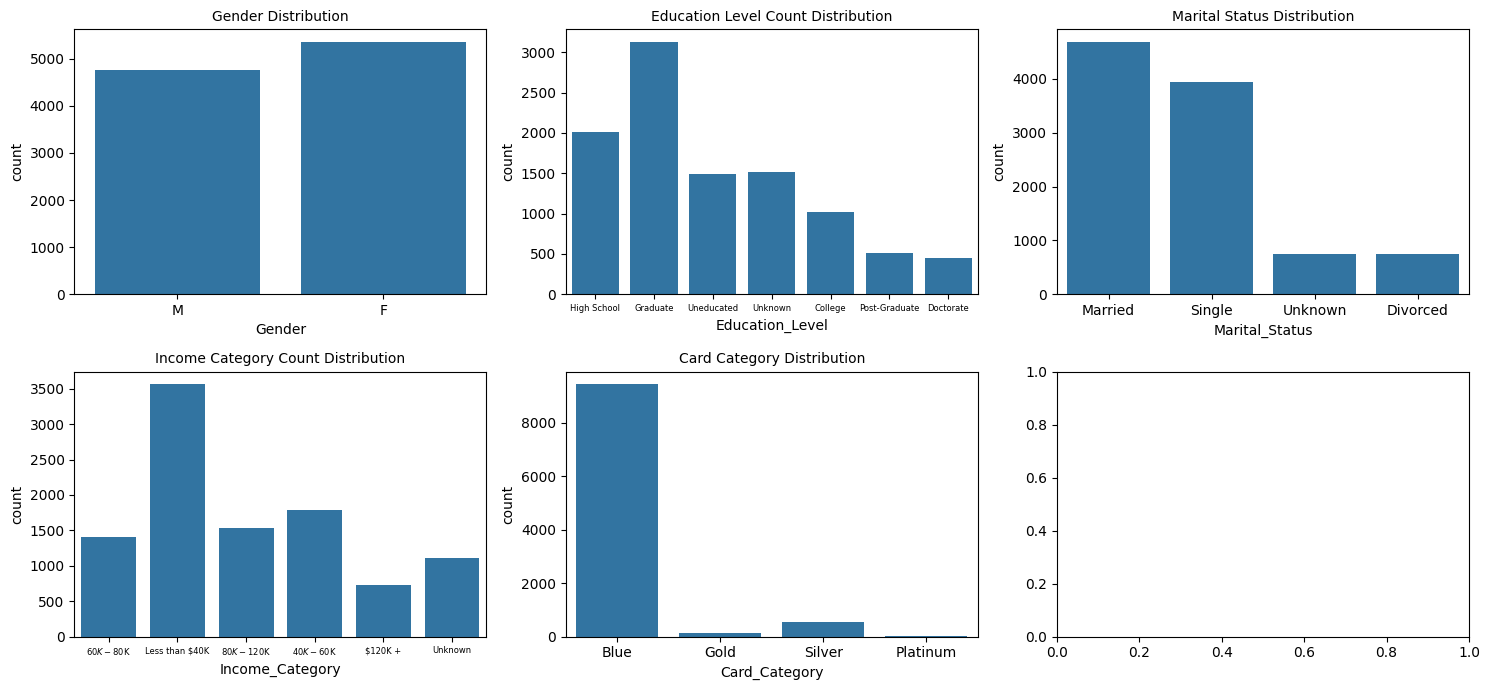

In [11]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# Plot Gender Distribution
sns.countplot(x=df['Gender'], ax=axes[0, 0])
axes[0, 0].set_title("Gender Distribution", fontsize=10)

# Plot Education Level Count Distribution
sns.countplot(x=df['Education_Level'], ax=axes[0, 1])
axes[0, 1].set_title("Education Level Count Distribution", fontsize=10)
axes[0, 1].tick_params(axis='x', labelsize=6)

# Plot Marital_Status Distribution
sns.countplot(x=df['Marital_Status'], ax=axes[0, 2])
axes[0, 2].set_title("Marital Status Distribution", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=df['Income_Category'], ax=axes[1, 0])
axes[1, 0].set_title("Income Category Count Distribution", fontsize=10)
axes[1, 0].tick_params(axis='x', labelsize=6)

# Plot Card_Category Distribution
sns.countplot(x=df['Card_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Card Category Distribution", fontsize=10)


# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

# Data Processing

### Viewing data

In [12]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [13]:
df_subset = df[['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count',
                'Months_Inactive_12_mon','Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal','Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']]

### Encoding Categorical Data

In [14]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


In [15]:
for col in df_subset[['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']]:
    print(df_subset[col].unique())

['M' 'F']
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
['Married' 'Single' 'Unknown' 'Divorced']
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
['Blue' 'Gold' 'Silver' 'Platinum']


In [16]:
df_subset = df_subset.copy()

# Using Label Encoding for Attrition_Flag,Gender & Martial_Status
label_encoder = LabelEncoder()


df_subset['Gender'] = label_encoder.fit_transform(df_subset['Gender'])
df_subset['Marital_Status'] = label_encoder.fit_transform(df_subset['Marital_Status'])

In [17]:
df_subset = df_subset.copy()

# Define ordered categories
education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
card_order = ["Blue", "Silver", "Gold", "Platinum"]

# Ensure the columns are strings
df_subset['Education_Level'] = df_subset['Education_Level'].astype(str)
df_subset['Income_Category'] = df_subset['Income_Category'].astype(str)
df_subset['Card_Category'] = df_subset['Card_Category'].astype(str)

In [18]:
# Apply Ordinal Encoding
ordinal_encoder_education = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Education_Level'] = ordinal_encoder_education.fit_transform(df_subset[['Education_Level']]).astype(float)

ordinal_encoder_income = OrdinalEncoder(categories=[income_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Income_Category'] = ordinal_encoder_income.fit_transform(df_subset[['Income_Category']]).astype(float)

ordinal_encoder_card = OrdinalEncoder(categories=[card_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Card_Category'] = ordinal_encoder_card.fit_transform(df_subset[['Card_Category']]).astype(float)

In [19]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,int64
Dependent_count,int64
Education_Level,float64
Marital_Status,int64
Income_Category,float64
Card_Category,float64
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


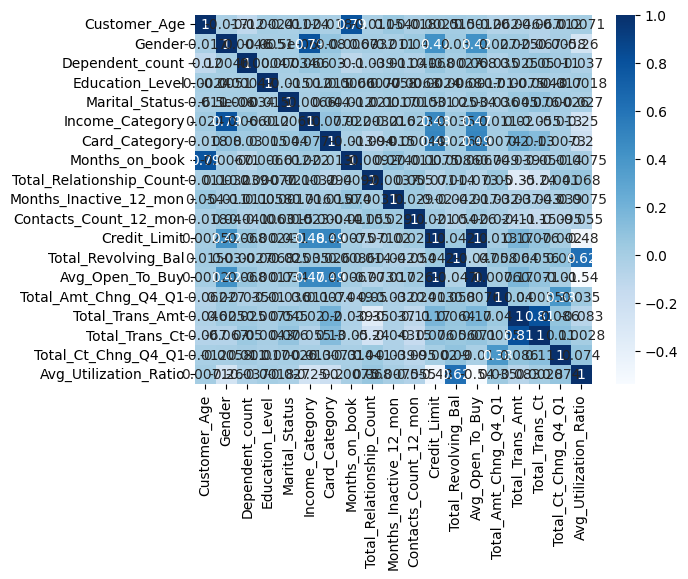

In [20]:
corr = df_subset.corr()
sns.heatmap(corr, cmap="Blues", annot=True)
sns.set_theme(rc={'figure.figsize':(15,15)})

In [21]:
kmeans_data  = df_subset.copy()
kmeans_data_clustered = df_subset.copy()
gmm_data  = df_subset.copy()
gmm_data_clustered = df_subset.copy()
hc_data  = df_subset.copy()
hc_data_clustered = df_subset.copy()
dbscan_data  = df_subset.copy()
dbscan_data_clustered = df_subset.copy()
df_cleaned = df_subset.copy()

### Feature Scaling

We will now apply feature scaling to

In [22]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

In [23]:
df_scaled = pd.DataFrame(df_scaled)

df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,-0.165406,1.059956,0.503368,-0.354022,-0.628128,0.620039,-0.250587,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882
1,0.333570,-0.943436,2.043199,0.822218,0.727306,-0.736292,-0.250587,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276
2,0.583058,1.059956,0.503368,0.822218,-0.628128,1.298204,-0.250587,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155
3,-0.789126,-0.943436,1.273283,-0.354022,2.082739,-0.736292,-0.250587,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686
4,-0.789126,1.059956,0.503368,-0.942142,-0.628128,0.620039,-0.250587,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155


# Hierarchical Clustering

## Modelling

### Plotting Dendrogram

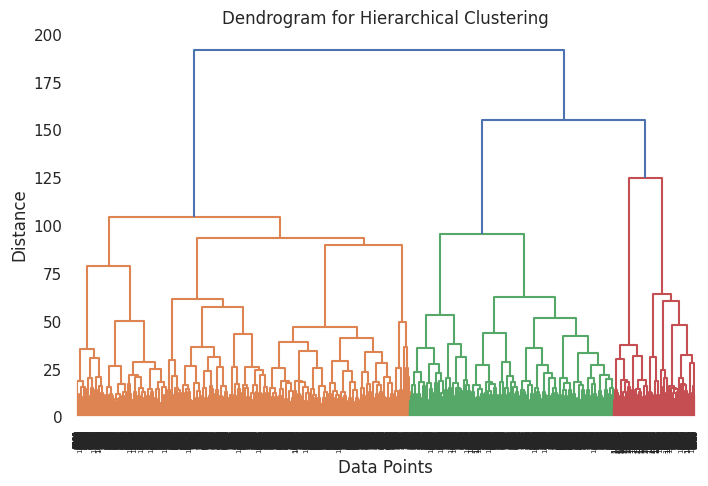

In [24]:
# Create the linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Running Hierarchical Clustering

In [25]:
# We will use 5 clusters as suggested by the Dendrogram
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_clustered = hc.fit_predict(df_scaled)

In [26]:
hc_segmented = hc_clustered.copy()

hc_data_clustered['Cluster'] = hc_segmented

## Plotting Clusters Distribution

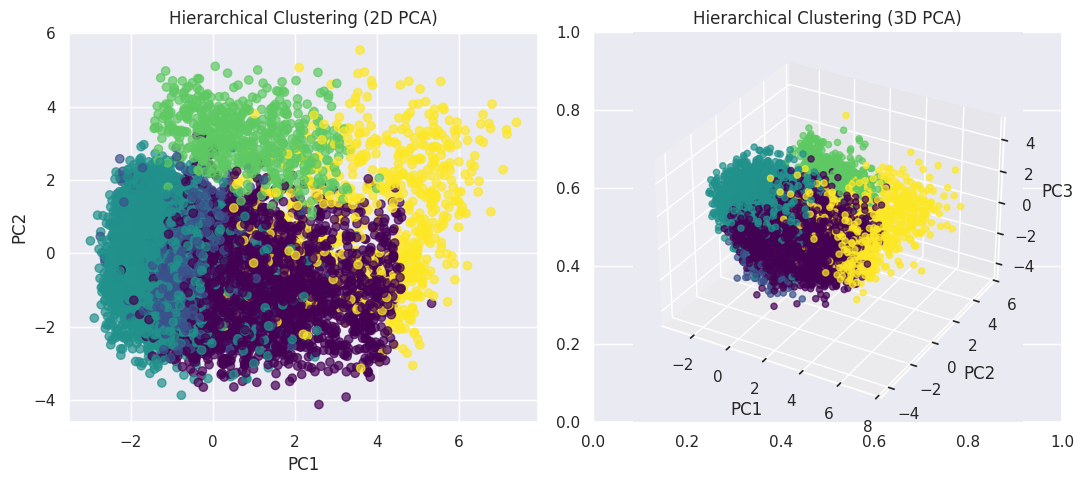

In [27]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=hc_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Hierarchical Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=hc_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("Hierarchical Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [28]:
#df_scaled['Cluster']=sch.fcluster(linkage_matrix, t=5, criterion='maxclust')
#df_sorted = df.sort_values(by='Cluster')
df_scaled['Cluster'] = hc_clustered
print(df_scaled.head())  # View the dataset with assigned clusters
cluster_counts = df_scaled['Cluster'].value_counts()
print(cluster_counts)

          0         1         2         3         4         5         6  \
0 -0.165406  1.059956  0.503368 -0.354022 -0.628128  0.620039 -0.250587   
1  0.333570 -0.943436  2.043199  0.822218  0.727306 -0.736292 -0.250587   
2  0.583058  1.059956  0.503368  0.822218 -0.628128  1.298204 -0.250587   
3 -0.789126 -0.943436  1.273283 -0.354022  2.082739 -0.736292 -0.250587   
4 -0.789126  1.059956  0.503368 -0.942142 -0.628128  0.620039 -0.250587   

          7         8         9        10        11        12        13  \
0  0.384621  0.763943 -1.327136  0.492404  0.446622 -0.473422  0.488971   
1  1.010715  1.407306 -1.327136 -0.411616 -0.041367 -0.366667 -0.008486   
2  0.008965  0.120579 -1.327136 -2.219655 -0.573698 -1.426858 -0.445658   
3 -0.241473 -0.522785  1.641478 -1.315636 -0.585251  1.661686 -0.734100   
4 -1.869317  0.763943 -1.327136 -2.219655 -0.430877 -1.426858 -0.302868   

         14        15        16         17        18  Cluster  
0  2.623494 -0.959707 -0.973895   

In [29]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(hc_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0    3333
1    1507
2    3956
3     564
4     767
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

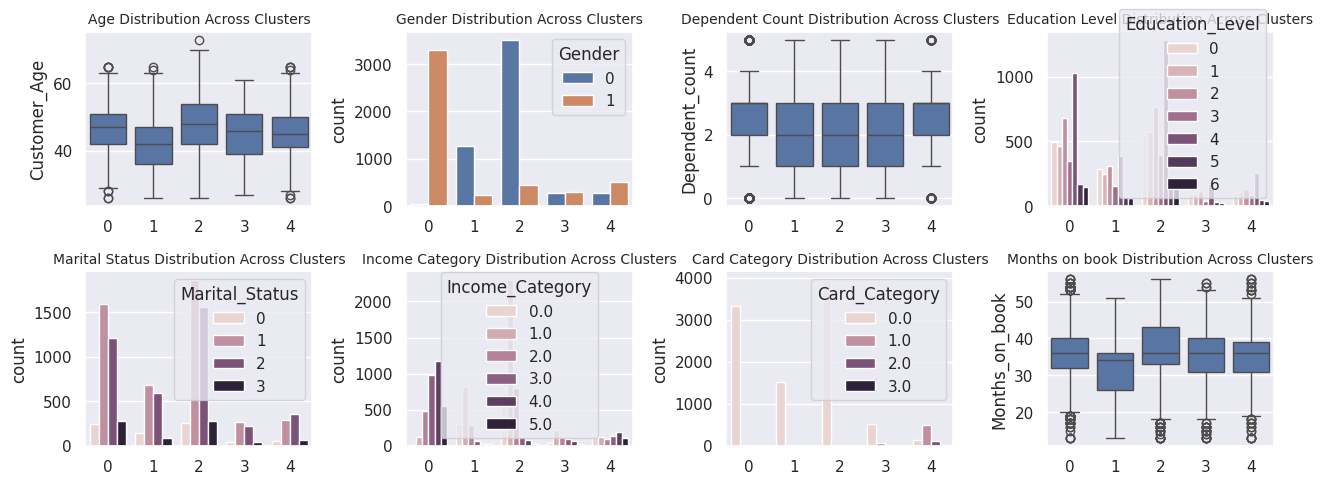

In [30]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [31]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,46.535854,0.990699,2.572157,2.615062,1.458746,3.461746,0.001500,36.193819
1,41.383543,0.155275,2.261447,2.370272,1.412077,1.173192,0.000000,31.319841
2,48.370071,0.112487,2.172396,2.672649,1.467897,1.185288,0.001769,37.749747
3,45.102837,0.508865,2.195035,2.464539,1.452128,2.012411,0.097518,34.976950
4,45.481095,0.653194,2.538462,2.736636,1.569752,2.597132,1.016949,35.135593


### Transactional Data

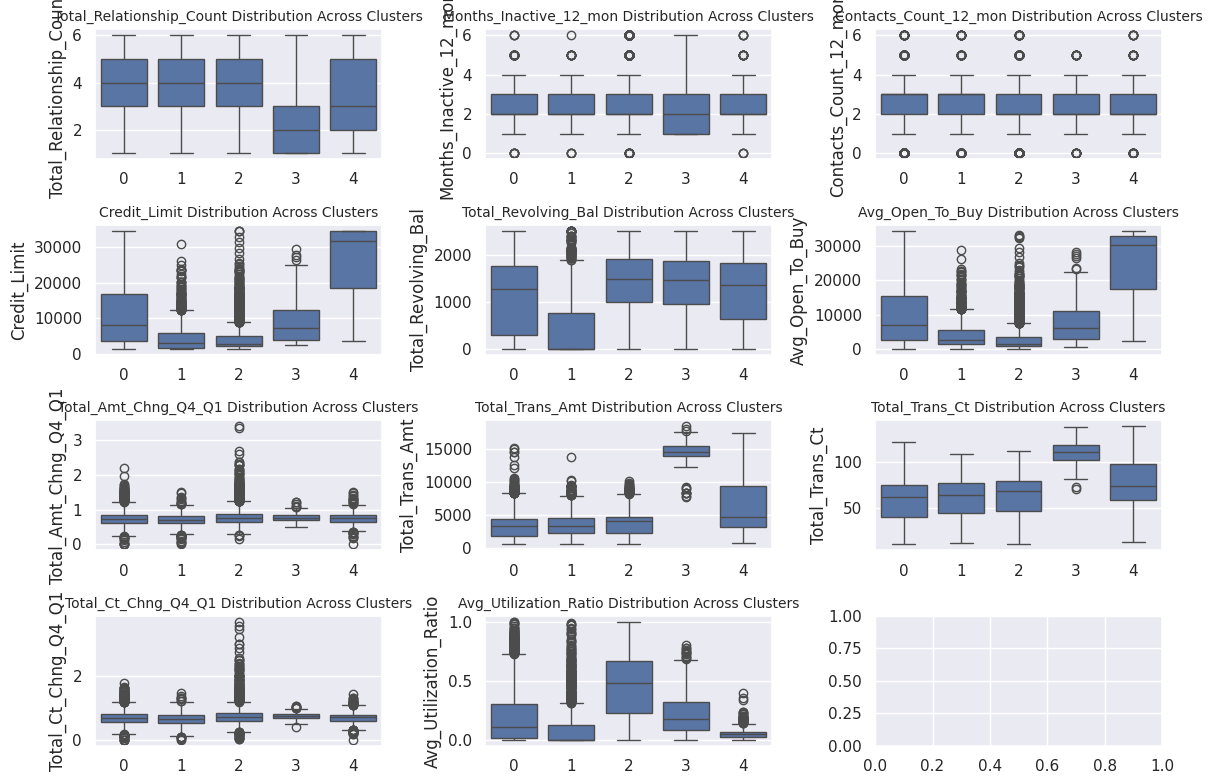

In [32]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=hc_clustered, y=hc_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [33]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,3.942694,11443.730123,10279.645215,3435.159016,58.661566,0.204265
1,3.885202,4546.830325,4148.862177,3523.972794,61.079628,0.098979
2,3.981547,4237.820854,2820.638094,3604.635996,62.870829,0.452448
3,2.312057,8867.157801,7509.959220,14631.301418,109.897163,0.220819
4,3.336375,26930.734029,25725.584094,6946.774446,76.348110,0.051425


## Cluster Analysis

*   **Cluster 0: Mid-High Income Males with Dependents, Strong Banking Relationship**
      - Likely financially stable men managing family expenses with good banking engagement and responsible credit use.
*   **Cluster 1: Young, Low-Income Females with Shortest Tenure & Low Credit**
      - Newer bank customers with limited financial history, lower credit access, and cautious spending.
*   **Cluster 2: Older, Low-Income Females with Strong Banking Relationship & High Utilisation**
      - Long-term customers with lower incomes, relying heavily on credit, possibly facing financial constraints.
*  **Cluster 3: Mid-Income Graduates with High Spending & Transactions**
      - Likely financially independent individuals who spend actively but don’t engage deeply with the bank.
*   **Cluster 4: Educated, Single Individuals with High Credit & Low Utilisation**
      - Financially stable, independent, and responsible spenders who manage credit well.




#Decisiont Tree and Random Forest

RF model training

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

train_test split

In [35]:
X = df_scaled.drop(columns=['Cluster'])
y = df_scaled['Cluster']
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (10127, 19)
y shape: (10127,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

decision tree

In [37]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display a classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       658
           1       0.63      0.68      0.65       298
           2       0.92      0.78      0.84       798
           3       0.85      0.80      0.83       106
           4       0.93      0.78      0.85       166

    accuracy                           0.83      2026
   macro avg       0.83      0.81      0.81      2026
weighted avg       0.84      0.83      0.83      2026



random forest

In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display a classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       658
           1       0.87      0.78      0.82       298
           2       0.93      0.92      0.93       798
           3       0.94      0.96      0.95       106
           4       0.96      0.95      0.95       166

    accuracy                           0.92      2026
   macro avg       0.92      0.92      0.92      2026
weighted avg       0.92      0.92      0.92      2026



#XGboost

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display a classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       658
           1       0.86      0.79      0.82       298
           2       0.93      0.93      0.93       798
           3       0.93      0.97      0.95       106
           4       0.97      0.94      0.95       166

    accuracy                           0.93      2026
   macro avg       0.92      0.92      0.92      2026
weighted avg       0.92      0.93      0.92      2026



Decision tree has the problem of overfitting, through bagging, the Random Forest got better performance. Both Random Forest and XGBoost demonstrates a high accuracy score, with XGboost performs slightly better

# Citations

BAI. (2012). The New Dynamics of Consumer Banking Relationships. BAI Research Study. https://www.bai.org/banking-strategies/segmentation-comes-of-age/.

Latinia. (2024). Customer segmentation in banking: Building High-Impact Strategies. https://latinia.com/en/resources/customer-segmentation-banking-insights.